# Toxic Comment Classification with Flan-T5 (Transfer Learning)

Fine-tuning Google's **Flan-T5 base** (encoder-decoder Transformer) to classify toxic comments into three categories — **insult**, **threat**, **sexual harassment** — using a text-to-text instruction approach with prompt engineering.

- Data: `train.csv` / `test.csv` (Toxic Comments dataset, 5,910 labeled comments), columns `Toxic Comment` and `Classification`
- 85/15 stratified train-validation split, label padding masked with -100
- Result: **91.77% accuracy**, **F1-Macro 0.9172** on the validation split (see `reports/` deck for the full evaluation)

*Group 4 — Statistical Machine Learning, Statistics, Diponegoro University.*

> Originally run on Google Colab (GPU). Adjust the data paths in the cell below to your environment.

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainer, Seq2SeqTrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
# 1. Load Data
train_df = pd.read_csv('/content/drive/MyDrive/SML/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/SML/test.csv')

# Bersihkan teks dari NaN
train_df['Toxic Comment'] = train_df['Toxic Comment'].fillna("")
test_df['Toxic Comment'] = test_df['Toxic Comment'].fillna("")

# --- PENYESUAIAN PROMPT DAN LABEL ---
# Kita beri tahu T5 persis apa opsi jawabannya sesuai dataset Anda
prefix = "Classify this comment as insult, threat, or sexual harassment: "

train_df['t5_input'] = prefix + train_df['Toxic Comment'].astype(str)
test_df['t5_input'] = prefix + test_df['Toxic Comment'].astype(str)

# T5 butuh target teks dalam huruf kecil agar konsisten
train_df['t5_target'] = train_df['Classification'].astype(str).str.lower().str.strip()

# Hapus baris kosong jika ada
train_df = train_df[train_df['t5_target'] != "nan"]

# ------------------------------------

# Lanjut ke Train-Validation Split...
df_train, df_val = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df['Classification'],
    random_state=42
)

Jumlah per Kelas:
Classification
Insult               2169
Threat               1981
Sexual Harassment    1761
Name: count, dtype: int64

Persentase per Kelas:
Classification
Insult               36.694299
Threat               33.513788
Sexual Harassment    29.791913
Name: proportion, dtype: float64


/tmp/ipykernel_7057/581880946.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


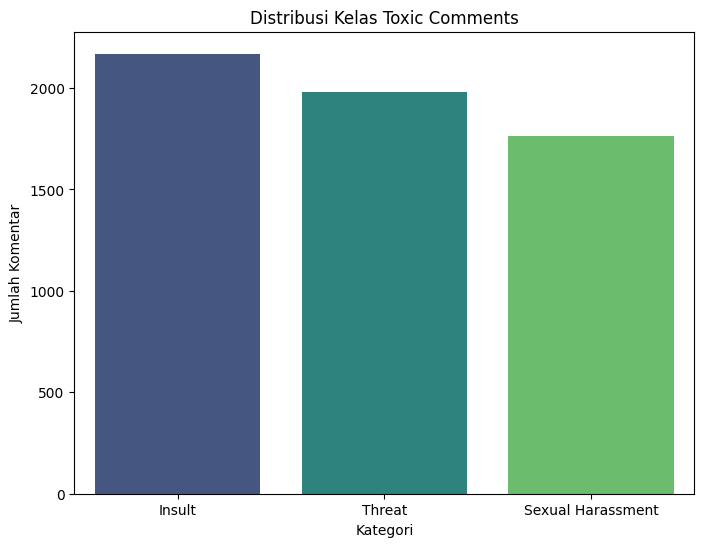

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menghitung jumlah per kategori
class_counts = train_df['Classification'].value_counts()
class_percentage = train_df['Classification'].value_counts(normalize=True) * 100

print("Jumlah per Kelas:")
print(class_counts)
print("\nPersentase per Kelas:")
print(class_percentage)

# 2. Visualisasi dengan Bar Chart
plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribusi Kelas Toxic Comments')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Komentar')
plt.show()

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from datasets import Dataset

# 1. Download/Load Model dan Tokenizer Flan-T5
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

# 2. Fungsi Tokenisasi (Termasuk trik -100 untuk target)
def preprocess_function(examples):
    # Tokenisasi Input (Komentar + Prompt)
    model_inputs = tokenizer(examples["t5_input"], max_length=128, padding="max_length", truncation=True)

    # Tokenisasi Target (Label Text: "insult", "threat", dll)
    labels = tokenizer(examples["t5_target"], max_length=10, padding="max_length", truncation=True)

    # Ubah padding token menjadi -100
    labels["input_ids"] = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label] for label in labels["input_ids"]
    ]
    model_inputs["labels"] = labels["input_ids"]

    return model_inputs

# 3. Konversi Data Pandas ke format Hugging Face Dataset
ds_train = Dataset.from_pandas(df_train[['t5_input', 't5_target']])
ds_val = Dataset.from_pandas(df_val[['t5_input', 't5_target']])

# 4. Eksekusi Tokenisasi
print("Mulai proses tokenisasi...")
tokenized_train = ds_train.map(preprocess_function, batched=True)
tokenized_val = ds_val.map(preprocess_function, batched=True)
print("Tokenisasi selesai!")

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Mulai proses tokenisasi...


Map:   0%|          | 0/5024 [00:00<?, ? examples/s]

Map:   0%|          | 0/887 [00:00<?, ? examples/s]

Tokenisasi selesai!


In [ ]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

# 1. Setup Argumen Training
training_args = Seq2SeqTrainingArguments(
    output_dir="./results_flan_t5",
    num_train_epochs=5,              # Kita coba 3 putaran belajar
    per_device_train_batch_size=8,   # Jika memori GPU Anda tidak kuat (OOM), turunkan menjadi 4
    per_device_eval_batch_size=8,
    eval_strategy="epoch",     # Evaluasi akurasi setiap 1 epoch selesai
    save_strategy="epoch",
    load_best_model_at_end=True,     # Otomatis menyimpan model dengan F1-Score tertinggi
    learning_rate=3e-4,
    predict_with_generate=True,      # WAJIB TRUE untuk Flan-T5 karena dia menghasilkan teks
    report_to="none"
)

# 2. Fungsi untuk menghitung F1-Score dari teks output
def compute_metrics_t5(eval_preds):
    preds, labels = eval_preds

    # Kembalikan angka -100 menjadi pad_token agar bisa diubah balik jadi teks
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    # Decode angka menjadi teks ("insult", dll)
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Rapikan dan samakan huruf kecil
    decoded_preds = [pred.strip().lower() for pred in decoded_preds]
    decoded_labels = [label.strip().lower() for label in decoded_labels]

    # Hitung F1 Macro
    f1 = f1_score(decoded_labels, decoded_preds, average='macro', zero_division=0)
    acc = accuracy_score(decoded_labels, decoded_preds)
    return {"f1_macro": f1, "accuracy": acc}

# 3. Masukkan semuanya ke dalam Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    compute_metrics=compute_metrics_t5
)

# 4. MULAI TRAINING!
print("Memulai proses fine-tuning Flan-T5...")
trainer.train()

Memulai proses fine-tuning Flan-T5...


Epoch,Training Loss,Validation Loss,F1 Macro,Accuracy
1,2.019495,0.240990,0.887870,0.888388
2,0.253161,0.185738,0.903673,0.904171
3,0.159790,0.162619,0.903869,0.904171
4,0.104340,0.176104,0.903862,0.904171
5,0.088677,0.189212,0.902769,0.903044


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


TrainOutput(global_step=3140, training_loss=0.44383441019969383, metrics={'train_runtime': 1447.9988, 'train_samples_per_second': 17.348, 'train_steps_per_second': 2.169, 'total_flos': 4300276173373440.0, 'train_loss': 0.44383441019969383, 'epoch': 5.0})

In [ ]:
print("--- Memulai Prediksi pada Data Test ---")

# 1. Siapkan data test ke dalam format Hugging Face Dataset
# Kita ambil kolom 't5_input' yang sudah diberi prompt sebelumnya
ds_test = Dataset.from_pandas(test_df[['t5_input']])

# 2. Tokenisasi data test
def preprocess_test(examples):
    return tokenizer(examples["t5_input"], max_length=128, padding="max_length", truncation=True)

tokenized_test = ds_test.map(preprocess_test, batched=True)

# 3. Lakukan Prediksi (Model akan mulai "mengetik" jawabannya)
print("Model sedang berpikir dan mengklasifikasikan data test...")
predictions = trainer.predict(tokenized_test)

# Ambil token hasil prediksi
generated_tokens = predictions.predictions

# 4. Ubah angka token kembali menjadi teks yang bisa dibaca manusia
decoded_preds = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)

# 5. Format teks agar rapi (Title Case: "insult" -> "Insult")
# Kita juga pastikan kalau model "berhalusinasi" kata lain, kita tangani (opsional)
valid_labels = ["Insult", "Threat", "Sexual Harassment"]
final_formatted_preds = []

for pred in decoded_preds:
    cleaned_pred = pred.strip().title()
    if cleaned_pred in valid_labels:
        final_formatted_preds.append(cleaned_pred)
    else:
        # Jika model menghasilkan kata aneh, kita default ke kelas paling aman/mayoritas
        # (Anda bisa ganti "Insult" dengan kelas mayoritas di dataset Anda)
        final_formatted_preds.append("Insult")

# 6. Buat DataFrame Submission
submission = pd.DataFrame({
    'id': test_df['id'],  # Pastikan kolom ID sesuai dengan file test.csv
    'Classification': final_formatted_preds
})

# 7. Simpan ke CSV
nama_file = 'submission_flan_t5_terbaru.csv'
submission.to_csv(nama_file, index=False)

print(f"\nSelesai! File '{nama_file}' sudah berhasil dibuat.")

--- Memulai Prediksi pada Data Test ---


Map:   0%|          | 0/1478 [00:00<?, ? examples/s]

Model sedang berpikir dan mengklasifikasikan data test...



Selesai! File 'submission_flan_t5_terbaru.csv' sudah berhasil dibuat.
